# Altimetry time series for Duck

## Paths and settings

In [1]:
# paths jupyter utwente
path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/output/'

https://spatialreference.org/explorer.html?latlng=36.168923,-75.751076&ignoreWorld=true&allowDeprecated=false&authorities=EPSG&activeTypes=PROJECTED_CRS  
https://spatialreference.org/ref/epsg/2264/  
https://spatialreference.org/ref/epsg/32618/  

In [2]:
epsg_in = 4326
epsg_out = 32618 # 32618 2264 local system only required for binning altimetry points into cells
overwrite = False # True: overwrite existing files, False: do not overwrite

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import os
import xarray as xr
import numpy as np
import pandas as pd
from scipy import stats
import geojson
from shapely import Polygon
    
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.feature import LAND

from coastal_data import CD_helper_functions, CD_altimetry, CD_data_preparation

import pdb

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Data

### IB correction

In [4]:
fn = 'ib_correction_era5.nc'
if (not os.path.isfile(path_input_general+fn)) | overwrite:
    corr = CD_altimetry.compute_ib_corr(path_input_general)

ibcorr = xr.open_dataset(path_input_general + fn)

Text(0.5, 1.0, 'IB correction in [m]')

<Figure size 2000x1000 with 0 Axes>

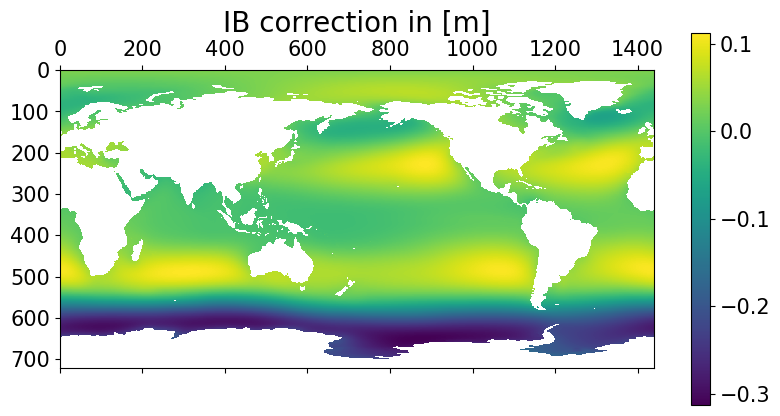

In [5]:
plt.figure(1, figsize=(20,10))
plt.matshow(ibcorr.mean('time').IB_correction)
plt.colorbar()
plt.title('IB correction in [m]')

masked array to xarray, fill value 0, but land areas filled with -20.000  
in the old version (from paper 1), this was automatically 0  
not sure if this affects the correction in the end  
error would be probably so huge that we would see it  

### PSMSL Tide gauge

In [6]:
fn = 'psmsl_monthly_RLR_DUCK.txt'
tg_psmsl_orig = pd.read_csv(f'{path_input}/{fn}', sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

tg_psmsl['SSH_RLR[cm]'] = tg_psmsl_orig['SSH_RLR[mm]'].values / 10
# if absolute ssh needed, convert RLR to benchmark: https://psmsl.org/data/obtaining/rlr.diagrams/1636.php

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

# remove 9999.0
idx, = np.where(tg_psmsl['SSH_RLR[cm]'] < 1000)
tg_psmsl= tg_psmsl.iloc[idx]

In [7]:
# IB correction
psmsl_lat = 53.363
psmsl_lon = 5.220

psmsl_ibcorr = ibcorr.interp(lat=psmsl_lat, lon=psmsl_lon, method="linear")
time_ib = pd.to_datetime(psmsl_ibcorr.time, utc=True)
values_ib = psmsl_ibcorr.IB_correction

time_psmsl = tg_psmsl.index

ib_at_psmsl_times = np.interp(time_psmsl, time_ib, values_ib)

tg_psmsl['corr_ib[cm]'] = ib_at_psmsl_times * 100

### OpenADB ALES

In [8]:
# Select which missions to use
missions = [
            'Envisat (Version 3)', # 21.06.2002 - 11.10.2010
            'Jason-1',             # 15.01.2002 - 14.01.2009
            # 'Jason-1 (EM)',      # 10.02.2009 - 02.03.2012
            # 'Jason-1 (GM)',      # 11.05.2012 - 17.06.2013
            'Jason-2',             # 12.07.2008 - 30.09.2016
            # 'Jason-2 (EM)',      # 15.10.2016 - 17.05.2017
            'Jason-3',             # 18.02.2016 - 20.04.2019
            'Saral',               # 17.03.2013 - 28.06.2016
            # 'Saral (DP)',        # 05.07.2016 - 14.04.2019
            'Sentinel-3A',         # 24.11.2017 - 04.04.2020
            'Sentinel-3B',         # 26.11.2018 - 12.04.2020
           ]

# Merge all .nc-files
fn = 'ales.nc'
if (not os.path.isfile(path_output + fn)):
    ales = CD_altimetry.combine_openadb_nc_files(path_input + '2_Duck_OpenADB')
    ales = CD_altimetry.select_missions(ales, missions)
    # Clean according to OpenADB instructions (e.g. dist to coast, std, ...)
    ales = CD_altimetry.clean_openadb_ales(ales)
    ales.to_netcdf(path_output + fn)
else:
    ales = xr.open_dataset(path_output + fn)

Cells extracted: 48 49 50 38 39

In [9]:
# Make/load timeseries
fn = f'ales_ts_epgs{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'glon', 'lat':'glat', 'sla':None, 'ssh':'ssh', 'mssh':'mssh'}
    
    tg = tg_psmsl['SSH_RLR[cm]'] - tg_psmsl['corr_ib[cm]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'2003-01-01', 'max':'2020-01-01'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    %matplotlib inline
    ales_ts = CD_altimetry.get_altimetry_timeseries_with_TG(ales, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    ales_ts.to_csv(path_output+fn)
else:
    ales_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

### RADS T/P

In [10]:
path_tp = f'{path_input}1_marge_topexA_Duck/'
tx_152 = xr.open_dataset(path_tp+'rads2nc_pass152.nc')
tx_167 = xr.open_dataset(path_tp+'rads2nc_pass167.nc')
tx_228 = xr.open_dataset(path_tp+'rads2nc_pass228.nc')
tx_243 = xr.open_dataset(path_tp+'rads2nc_pass243.nc')

tx_combined = xr.merge([tx_152, tx_167, tx_228, tx_243])
tx = CD_altimetry.clean_rads(tx_combined, 'ssha')

Cells extracted for T/P: 45 46 55 54 64 63 (epsg 28992 and epsg 32631) would be the best fitting cells  
80 79 69 68 67 57 would be closer to selection from ALES

cells extraced (same area as for ALES extracted): 38 39 40 27 28

In [11]:
# Make/load timeseries
fn = f'tx_ts_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'lon', 'lat':'lat', 'sla':'ssha', 'ssh':None, 'mssh':'mss_dtu15'}
    
    tg = tg_psmsl['SSH_RLR[cm]'] - tg_psmsl['corr_ib[cm]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'1993-01-31', 'max':'2002-03-31'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    # %matplotlib qt5
    tx_ts = CD_altimetry.get_altimetry_timeseries_with_TG(tx, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    tx_ts.to_csv(path_output+fn)
else:
    tx_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

## Remove bias between OpenADB and RADS timeseries

In [12]:
tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts.sla_temp_av, ales_ts.sla_temp_av)

There are 39 overlapping values in the same time period.
Bias: -0.09229320250097278 m


In [13]:
combined = pd.concat([tx_biased_to_ales, ales_ts.sla_temp_av])

### Compare result against tide gauge

In [16]:
alt_mean = np.nanmean(combined.values)
tg = (tg_psmsl['SSH_RLR[cm]'] - tg_psmsl['corr_ib[cm]'])/100
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

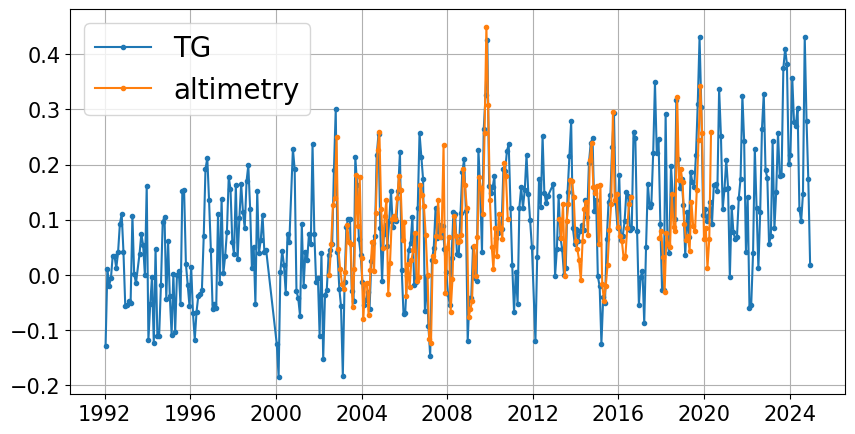

In [17]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined.index, combined.values, '.-', label='altimetry')
ax.grid()
ax.legend()

## Extract time series from polygon

In [60]:
path = '/home/jovyan/data/9_masks/'
fn = 'altimetry_duck_epsg32618.geojson'
with open(path+fn) as f:
    poly_duck = geojson.load(f)

duck_poly = Polygon(poly_duck['features'][0]['geometry']['coordinates'][0])

In [66]:
ales_ts_poly = CD_altimetry.get_altimetry_timeseries_from_polygon(ales['ssh']-ales['mssh'], ales['glon'], ales['glat'], ales['time'],
                                                                  epsg_in, epsg_out, duck_poly, freq_average='ME')

tx_ts_poly = CD_altimetry.get_altimetry_timeseries_from_polygon(tx['ssha'], tx['lon'], tx['lat'], tx['time'], epsg_in, epsg_out, duck_poly, freq_average='ME')

tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts_poly['sla'], ales_ts_poly['sla'])

combined_poly = pd.concat([tx_biased_to_ales, ales_ts_poly['sla']])
combined_poly = combined_poly.dropna()

### Compare result against tide gauge

In [93]:
alt_mean = np.nanmean(combined_poly.values)
tg = (tg_psmsl['SSH_RLR[cm]'] - tg_psmsl['corr_ib[cm]'])/100
tg_mean = np.nanmean(tg)
bias = tg_mean - alt_mean
tg_debias = tg - bias

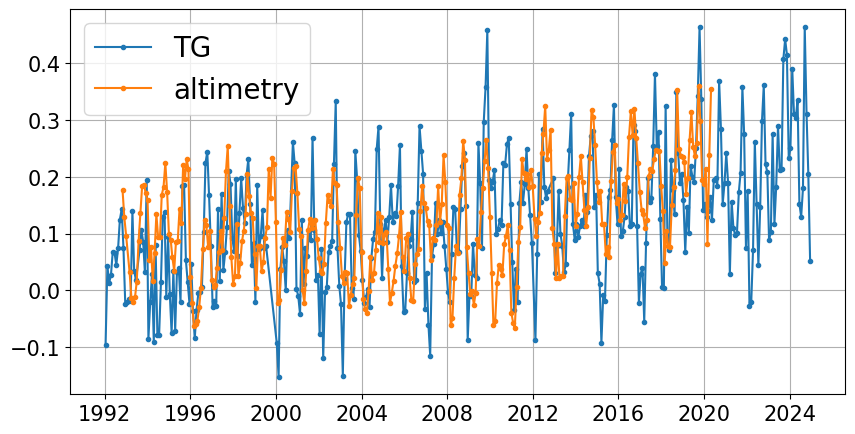

In [94]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(tg_psmsl.index, tg_debias, '.-', label='TG')
ax.plot(combined_poly.index, combined_poly.values, '.-', label='altimetry')
ax.grid()
ax.legend()

In [119]:
tg_at_alt_time = CD_altimetry.interpolate_tg_to_alt(combined_poly.index, tg_debias.index, tg_debias)

corr, p = stats.pearsonr(combined_poly, tg_at_alt_time)
print(f'corr: {round(corr,4)}, p-value: {p}')

rmse = CD_altimetry.compute_RMSE(combined_poly, tg_debias)
print(f'RMSE: {rmse}')

x = CD_helper_functions.datetime_to_decimal_numbers(tg_at_alt_time.index)
trend_tg = CD_statistics.compute_trend(x, tg_at_alt_time)
print(f'Trend from tide gauge: {trend_tg*1000} mm/year')

x = CD_helper_functions.datetime_to_decimal_numbers(combined_poly.index)
trend_alt = CD_statistics.compute_trend(x, combined_poly)
print(f'Trend from altimetry: {trend_alt*1000} mm/year')

corr: 0.5345, p-value: 8.862681442847574e-26
RMSE: 0.0
Trend from tide gauge: 5.3 mm/year
Trend from altimetry: 4.7 mm/year


In [120]:
fn = f'tp_plus_ales_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    combined.to_csv(path_output+fn)